In [1]:
import pandas as pd

In [18]:
df = pd.read_csv('/home/pkaczyns/Code/ALE-and-GNNs/data/citations/ALE_scalability_GAT_no_khop.csv', header=None, names=['i', 'k', 'max_bin_size', 'ALE exact', 'time_exact', 'ALE approximate', 'time_approximate', 'n_layers', 'hidden_size', 'no_exp', 'trial'])

In [7]:
df2 = pd.read_csv('/home/pkaczyns/Code/ALE-and-GNNs/data/citations/ALE_scalability_GCN.csv', header=None, names=['i', 'k', 'max_bin_size', 'ALE exact', 'time_exact', 'ALE approximate', 'time_approximate', 'n_layers', 'hidden_size', 'no_exp', 'trial'])

In [7]:
df2 = df2[df2['n_layers']==2]

In [11]:
df

,i,k,max_bin_size,ALE exact,time_exact,ALE approximate,time_approximate,n_layers,hidden_size,no_exp,trial
0,0,1024,8,0.001274,2.883831,-0.000277,0.424981,2,256,0,0
1,1,1024,8,0.004443,2.883831,0.000941,0.424981,2,256,0,0
2,2,1024,8,0.006054,2.883831,0.002812,0.424981,2,256,0,0
3,3,1024,8,0.006054,2.883831,0.002812,0.424981,2,256,0,0
4,4,1024,8,0.009554,2.883831,0.003925,0.424981,2,256,0,0
...,...,...,...,...,...,...,...,...,...,...,...
180,0,1024,1024,0.001670,196.933822,0.001757,0.470917,2,256,0,1
181,1,1024,1024,0.002649,196.933822,0.003178,0.470917,2,256,0,1
182,2,1024,1024,0.004379,196.933822,0.004979,0.470917,2,256,0,1
183,3,1024,1024,0.004379,196.933822,0.004979,0.470917,2,256,0,1


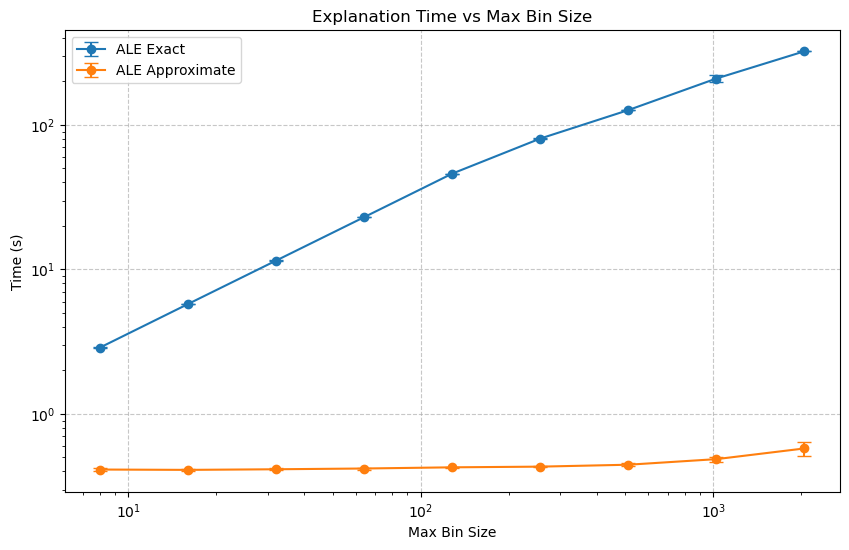

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. AGGREGATE DATA
# ---------------------------------------------------------

# Step A: Collapse the 5 consecutive rows (i=0..4) into one row per experiment ('no_exp').
# We take the mean, but since time is constant for a specific 'no_exp', 
# it effectively just grabs that unique time value.
per_experiment = df.groupby(['max_bin_size', 'no_exp', 'time_exact', 'time_approximate']).mean().reset_index()

# Step B: Calculate Mean and Error (Std Dev) across the different models (no_exp)
# for each unique max_bin_size.
plot_data = per_experiment.groupby('max_bin_size')[['time_exact', 'time_approximate']].agg(['mean', 'std'])

# Fill NaN standard deviations with 0 (happens if you only have 1 model per bin size)
plot_data = plot_data.fillna(0)

# 2. PLOTTING
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot Time Exact (Blue)
plt.errorbar(
    plot_data.index, 
    plot_data['time_exact']['mean'], 
    yerr=plot_data['time_exact']['std'], 
    fmt='-o', 
    capsize=5, 
    label='ALE Exact', 
    color='tab:blue'
)

# Plot Time Approximate (Orange)
plt.errorbar(
    plot_data.index, 
    plot_data['time_approximate']['mean'], 
    yerr=plot_data['time_approximate']['std'], 
    fmt='-o', 
    capsize=5, 
    label='ALE Approximate', 
    color='tab:orange'
)


# Formatting
plt.xlabel('Max Bin Size')
plt.ylabel('Time (s)')
plt.title('Explanation Time vs Max Bin Size')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.yscale('log')
plt.xscale('log')
plt.show()

In [61]:
import numpy as np
df['explanation'] = np.floor(df.index/5)

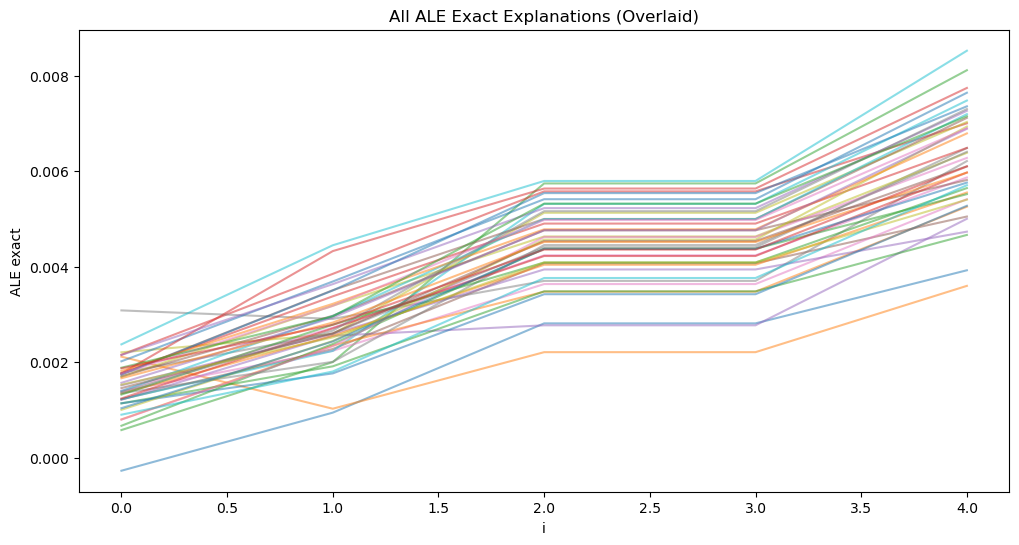

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Group the data
groups = df.groupby(['max_bin_size', 'no_exp', 'trial'])

# Iterate and plot each group on the same axis 'ax'
for name, group in groups:
    # We set legend=False to avoid creating a legend with hundreds of entries
    group.plot(x='i', y='ALE approximate', ax=ax, legend=False, alpha=0.5)

plt.ylabel('ALE exact')
plt.title('All ALE Exact Explanations (Overlaid)')
plt.show()

In [25]:
df.tail(45)

,i,k,max_bin_size,ALE exact,time_exact,ALE approximate,time_approximate,n_layers,hidden_size,no_exp,trial
175,0,1024,1024,0.001313,195.112663,0.001455,0.461250,2,256,0,0
176,1,1024,1024,0.002911,195.112663,0.002604,0.461250,2,256,0,0
177,2,1024,1024,0.004404,195.112663,0.004537,0.461250,2,256,0,0
178,3,1024,1024,0.004404,195.112663,0.004537,0.461250,2,256,0,0
179,4,1024,1024,0.006901,195.112663,0.006106,0.461250,2,256,0,0
180,0,1024,1024,0.001670,196.933822,0.001757,0.470917,2,256,0,1
181,1,1024,1024,0.002649,196.933822,0.003178,0.470917,2,256,0,1
182,2,1024,1024,0.004379,196.933822,0.004979,0.470917,2,256,0,1
183,3,1024,1024,0.004379,196.933822,0.004979,0.470917,2,256,0,1
184,4,1024,1024,0.006063,196.933822,0.006902,0.470917,2,256,0,1


In [64]:
rmse = df.groupby(['explanation', 'no_exp', 'max_bin_size']).apply(lambda x: np.sqrt(np.sum((x['ALE approximate']-x['ALE exact'])**2))).reset_index().rename({0:'rmse'}, axis=1)

/tmp/ipykernel_3240803/1266487370.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse = df.groupby(['explanation', 'no_exp', 'max_bin_size']).apply(lambda x: np.sqrt(np.sum((x['ALE approximate']-x['ALE exact'])**2))).reset_index().rename({0:'rmse'}, axis=1)


In [36]:
rmse.groupby(['max_bin_size'])['rmse'].agg(['mean', 'std'])

,mean,std
max_bin_size,,
8,0.006159,0.002500
16,0.004729,0.002806
32,0.002627,0.001095
64,0.001683,0.001006
128,0.001225,0.000645
256,0.000950,0.000533
512,0.000964,0.000381
1024,0.000969,0.000888
2048,0.000736,0.000527


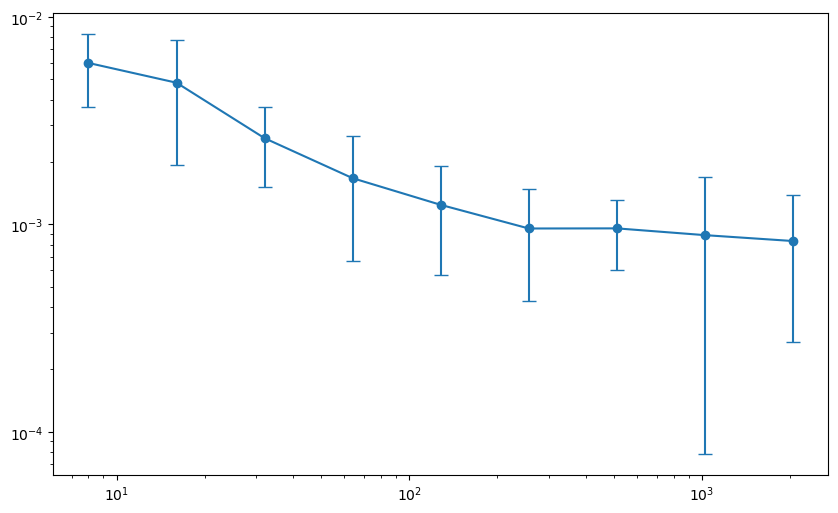

In [65]:
plt.figure(figsize=(10, 6))
p = rmse.groupby(['max_bin_size'])['rmse'].agg(['mean', 'std'])
plt.errorbar(
    p.index, 
    p['mean'], 
    yerr=p['std'], 
    fmt='-o', 
    capsize=5, 
    label='ALE Exact', 
    color='tab:blue'
)
plt.yscale('log')
plt.xscale('log')

In [40]:
df.tail(20)

,i,k,max_bin_size,ALE exact,time_exact,ALE approximate,time_approximate,n_layers,hidden_size,no_exp,explanation
635,0,1024,1024,-0.002753,188.118213,-0.002152,0.444294,2,256,2,127.0
636,1,1024,1024,-0.004728,188.118213,-0.003978,0.444294,2,256,2,127.0
637,2,1024,1024,-0.006611,188.118213,-0.006299,0.444294,2,256,2,127.0
638,3,1024,1024,-0.006611,188.118213,-0.006299,0.444294,2,256,2,127.0
639,4,1024,1024,-0.007659,188.118213,-0.007453,0.444294,2,256,2,127.0
640,0,1024,1024,-0.002907,191.373525,-0.002610,0.454721,2,256,2,128.0
641,1,1024,1024,-0.005111,191.373525,-0.005069,0.454721,2,256,2,128.0
642,2,1024,1024,-0.007667,191.373525,-0.007629,0.454721,2,256,2,128.0
643,3,1024,1024,-0.007667,191.373525,-0.007629,0.454721,2,256,2,128.0
644,4,1024,1024,-0.009118,191.373525,-0.008732,0.454721,2,256,2,128.0
